# **Clasificación basada en arboles / Proyecto 1 – Parte final**

# **Proyecto 1 (parte final): Análisis y Predicción de Ventas en una Tienda de Retail**

**Objetivo:** Realizar un análisis exploratorio de datos (EDA) completo, preprocesamiento y benchmarking de técnicas de machine learning para predecir ventas en una tienda de retail. Además, generar un análisis de métricas y crear una presentación de una página (one-page) en PPT para explicar los resultados.

In [73]:
# ==============================
# 1. LIBRERÍAS BASE
# ==============================
import pandas as pd
import numpy as np

# ==============================
# 2. VISUALIZACIÓN
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns
# ==============================
# 3. PREPROCESAMIENTO
# ==============================
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
# ==============================
# 4. MODELOS DE MACHINE LEARNING
# ==============================
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# ==============================
# 5. MÉTRICAS DE EVALUACIÓN
# ==============================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay
)
# ==============================
# 6. CONFIGURACIÓN GENERAL
# ==============================
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# **Parte 1: Exploración y Visualización de Datos (EDA)**

**Carga y Exploración de Datos**

In [74]:
# Carga de datos correctamente
df = pd.read_csv('/content/drive/MyDrive/DATASET/retail_sales_dataset.csv')
# Mostrar primeras y últimas filas
print("nprimeras y últimas filas del DataFrame:")
display(df.head())
print()
display(df.tail())

nprimeras y últimas filas del DataFrame:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [75]:
print("\nNúmero de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])


Número de filas: 1000
Número de columnas: 9


In [76]:
# Mostrar la información del DataFrame
print("\nInformación del DataFrame:")
print(df.info())


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None


In [77]:
print("\nTipos de datos:")
print(df.dtypes)


Tipos de datos:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


Los datos se presentan con una buena calidad, no se evidencian valores nulos ni registros duplicados en todas las variables analizadas. Lo anterior se presenta como una ventaja para el desarrollo del proyecto, ya que nos permite conservar la totalidad de las observaciones originales sin necesidad de aplicar técnicas de imputación o eliminación de registros que pudieran alterar la estructura del conjunto. Lo que nos otorga anticipadamente la confiabilidad de los resultados obtenidos durante la exploración y reduce la probabilidad de introducir sesgos en las etapas posteriores de preprocesamiento y modelamiento.

**Describir las variables y su distribución.**

In [78]:
# =============================================
# Estadística descriptiva variables numericas
# =============================================
# Mostrar la información estadistica del DataFrame
print("\nEstadística descriptiva Columnas numericas:")
display(df.describe())


Estadística descriptiva Columnas numericas:


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


La edad de los clientes presenta una distribución amplia, con valores comprendidos entre los 18 y los 64 años y una media cercana a los 41 años. Este resultado indica que la muestra representa principalmente a una población adulta económicamente activa, lo que resulta coherente con el contexto de consumo asociado al retail. La dispersión observada permite inferir que el comportamiento de compra podría estar influenciado por distintos perfiles etarios, aspecto que podría aportar capacidad explicativa durante el modelamiento.

La variable Quantity evidencia que la mayoría de las transacciones involucra un número reducido de unidades por compra, concentrándose entre una y cuatro unidades. Este patrón sugiere un comportamiento de compra frecuente pero de bajo volumen, situación habitual en entornos de venta minorista donde predominan las adquisiciones individuales por sobre las compras masivas.

Respecto al precio unitario y al monto total de venta, ambas variables presentan una dispersión considerable. Esta variabilidad resulta particularmente relevante debido a que refleja la coexistencia de productos con distintos niveles de valor económico dentro del catálogo comercial. Desde una perspectiva analítica, esta heterogeneidad es positiva para el desarrollo de modelos predictivos, ya que proporciona información suficiente para identificar patrones diferenciados de comportamiento de compra.

In [79]:
# =============================================
# Estadística descriptiva variables categóricas
# =============================================
print("Estadística descriptiva de variables categóricas:")

display(
    df.select_dtypes(include=['object']).describe()
)

Estadística descriptiva de variables categóricas:


,Date,Customer ID,Gender,Product Category
count,1000,1000,1000,1000
unique,345,1000,2,3
top,2023-05-16,CUST1000,Female,Clothing
freq,11,1,510,351


La variable género se distribuye de forma equilibrada entre clientes masculinos y femeninos, observándose una leve predominancia del segmento femenino. Siendo esta característica relevante para evitar desequilibrios importantes en la representación de grupos dentro de la muestra, permitiendo que los análisis posteriores reflejen de manera más adecuada el comportamiento general de los consumidores.

Por otra parte, la categoría de productos presenta una distribución relativamente homogénea entre Beauty, Clothing y Electronics. Aunque Clothing registra la mayor frecuencia de transacciones, las diferencias observadas respecto de las demás categorías son moderadas. Este comportamiento sugiere que el negocio mantiene una cartera de productos diversificada y que la demanda no depende exclusivamente de una única línea comercial, aspecto que puede favorecer la capacidad predictiva de los modelos al existir variabilidad suficiente entre categorías.

Un elemento adicional de interés corresponde a la variable Customer ID, la cual presenta una alta cardinalidad al existir prácticamente un identificador único para cada cliente. Desde el punto de vista predictivo, esta característica limita su aporte explicativo directo al comportamiento de compra, por lo que posteriormente deberá evaluarse su exclusión del modelo para evitar introducir ruido innecesario.

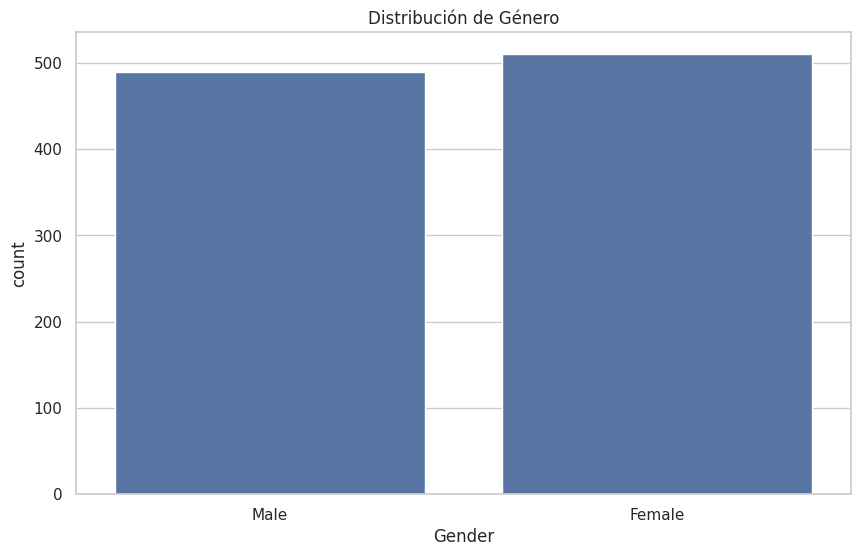



Interpretación: La distribución de género es equilibrada, con una leve predominancia del género femenino.
No se observa un desbalance significativo entre categorías.



In [80]:
# ========================================
# Distribución de Variables Categóricas
# ========================================
sns.countplot(data=df, x='Gender')
plt.title('Distribución de Género')
plt.show()
print()
print("""
Interpretación: La distribución de género es equilibrada, con una leve predominancia del género femenino.
No se observa un desbalance significativo entre categorías.
""")

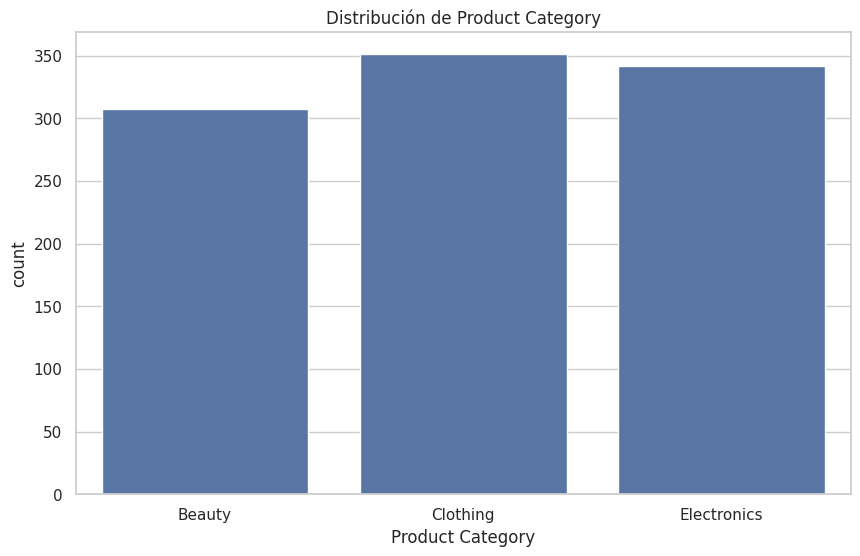



Interpretación: Las categorías de productos presentan una distribución relativamente homogénea.
La categoría Clothing es la más frecuente, seguida por Electronics y Beauty. No se observan 
categorías minoritarias que puedan generar problemas de representatividad.



In [81]:
# ========================================
# Distribución de Variables Categóricas
# ========================================
sns.countplot(data=df, x='Product Category')
plt.title('Distribución de Product Category')
plt.show()
print()
print("""
Interpretación: Las categorías de productos presentan una distribución relativamente homogénea.
La categoría Clothing es la más frecuente, seguida por Electronics y Beauty. No se observan
categorías minoritarias que puedan generar problemas de representatividad.
""")

**Identificar y tratar valores nulos y outliers.**

**Valores Nulos y Duplicados**

In [82]:
diccionario = pd.DataFrame({
    "Variable": df.columns,
    "Tipo Inicial": df.dtypes.values,
    "Valores No Nulos": df.count().values,
    "Valores Nulos": df.isnull().sum().values,
    "Porcentaje Nulos": (df.isnull().sum().values / len(df) * 100).round(2),
    "Valores Únicos": df.nunique().values
})

display(diccionario)

print("\nCantidad de filas duplicadas:")
print(df.duplicated().sum())

,Variable,Tipo Inicial,Valores No Nulos,Valores Nulos,Porcentaje Nulos,Valores Únicos
0,Transaction ID,int64,1000,0,0.0,1000
1,Date,object,1000,0,0.0,345
2,Customer ID,object,1000,0,0.0,1000
3,Gender,object,1000,0,0.0,2
4,Age,int64,1000,0,0.0,47
5,Product Category,object,1000,0,0.0,3
6,Quantity,int64,1000,0,0.0,4
7,Price per Unit,int64,1000,0,0.0,5
8,Total Amount,int64,1000,0,0.0,18



Cantidad de filas duplicadas:
0


**Outliers**

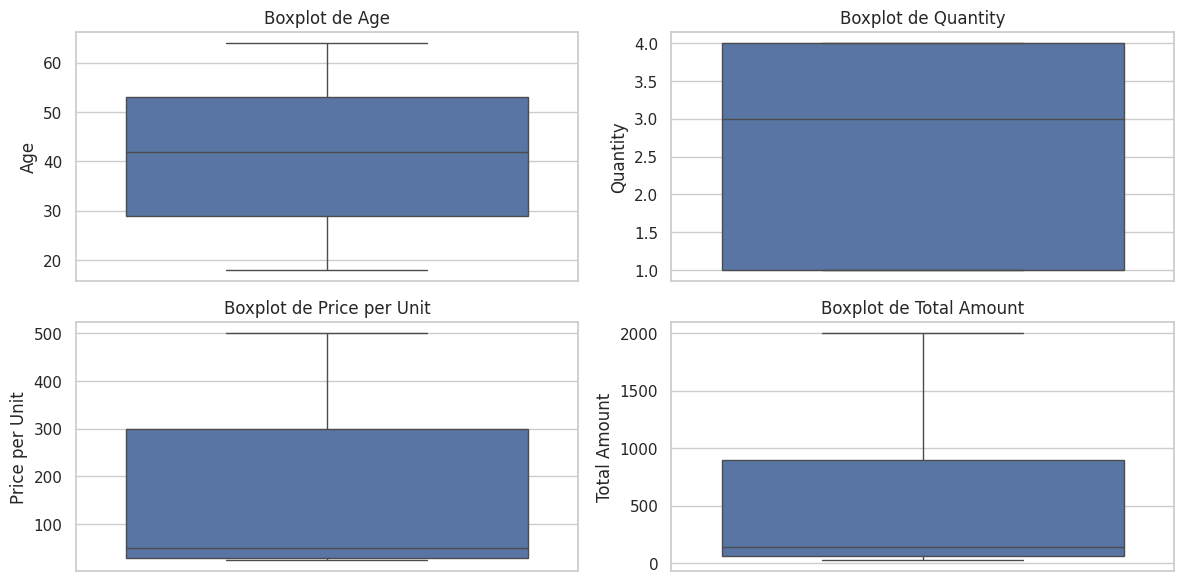



Conclusión: Mediante el análisis de boxplots no se identifican valores atípicos extremos
que puedan justificar la eliminación o transformación de observaciones. Dado que los 
valores observados corresponden a comportamientos razonable dentro del contexto de ventas 
retail, por lo que se decide mantener la totalidad de los registros para las etapas 
posteriores de modelado.



In [83]:
# ==========================================
# Identificación de Outliers
# ==========================================
numericas = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

plt.figure(figsize=(12,6))

for i, col in enumerate(numericas, 1):
    plt.subplot(2,2,i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()
print("""

Conclusión: Mediante el análisis de boxplots no se identifican valores atípicos extremos
que puedan justificar la eliminación o transformación de observaciones. Dado que los
valores observados corresponden a comportamientos razonable dentro del contexto de ventas
retail, por lo que se decide mantener la totalidad de los registros para las etapas
posteriores de modelado.
""")

La evaluación mediante diagramas de caja no evidenció observaciones claramente anómalas o inconsistentes con la lógica del negocio. Si bien algunas variables presentan una dispersión amplia, especialmente Price per Unit y Total Amount, los valores observados se encuentran dentro de rangos plausibles para un contexto retail.

Este hallazgo sugiere que las diferencias observadas corresponden más bien a variaciones naturales asociadas a distintos tipos de productos y niveles de gasto de los clientes que a errores de captura o registro. En consecuencia, no existe justificación metodológica para eliminar observaciones en esta etapa del análisis, permitiendo preservar la variabilidad original del fenómeno estudiado.

**Análisis de Correlación:**
Realizar un análisis de correlación y crear un mapa de calor para visualizar las relaciones entre las variables.

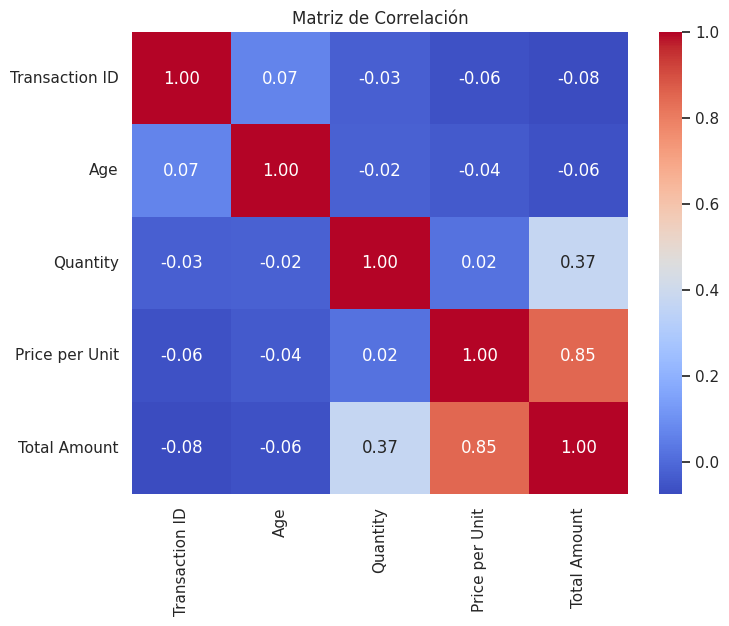


| Variables                     | Correlación |
| ----------------------------- | ----------- |
| Price per Unit - Total Amount |        0.85 |
| Quantity - Total Amount       |        0.37 |
| Age - Total Amount            |       -0.06 |
| Age - Quantity                |       -0.02 |
| Age - Price per Unit          |       -0.04 |


1. La variable Price per Unit presenta una correlación positiva fuerte (0.85)
con Total Amount, indicando que el precio unitario es el principal factor
asociado al monto total de las ventas.

2. La variable Quantity presenta una correlación positiva moderada (0.37)
con Total Amount, lo que sugiere que una mayor cantidad comprada también
contribuye al aumento de las ventas.

3. La variable Age muestra correlaciones muy bajas con las demás variables,
por lo que su influencia sobre el monto total parece limitada.

Conclusión: No se observan problemas evidentes de multicolinealidad entre las variables
predictoras analizadas.



In [84]:
# ==========================================
# Análisis de Correlación
# ==========================================
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de Correlación')
plt.show()

print("""
| Variables                     | Correlación |
| ----------------------------- | ----------- |
| Price per Unit - Total Amount |        0.85 |
| Quantity - Total Amount       |        0.37 |
| Age - Total Amount            |       -0.06 |
| Age - Quantity                |       -0.02 |
| Age - Price per Unit          |       -0.04 |
""")
print("""
1. La variable Price per Unit presenta una correlación positiva fuerte (0.85)
con Total Amount, indicando que el precio unitario es el principal factor
asociado al monto total de las ventas.

2. La variable Quantity presenta una correlación positiva moderada (0.37)
con Total Amount, lo que sugiere que una mayor cantidad comprada también
contribuye al aumento de las ventas.

3. La variable Age muestra correlaciones muy bajas con las demás variables,
por lo que su influencia sobre el monto total parece limitada.

Conclusión: No se observan problemas evidentes de multicolinealidad entre las variables
predictoras analizadas.
""")

**Visualización de Datos**

Crear subplots para comparar diferentes variables clave.
Añadir cuadrículas, leyendas, anotaciones y flechas a los gráficos para mejorar la claridad y la información.

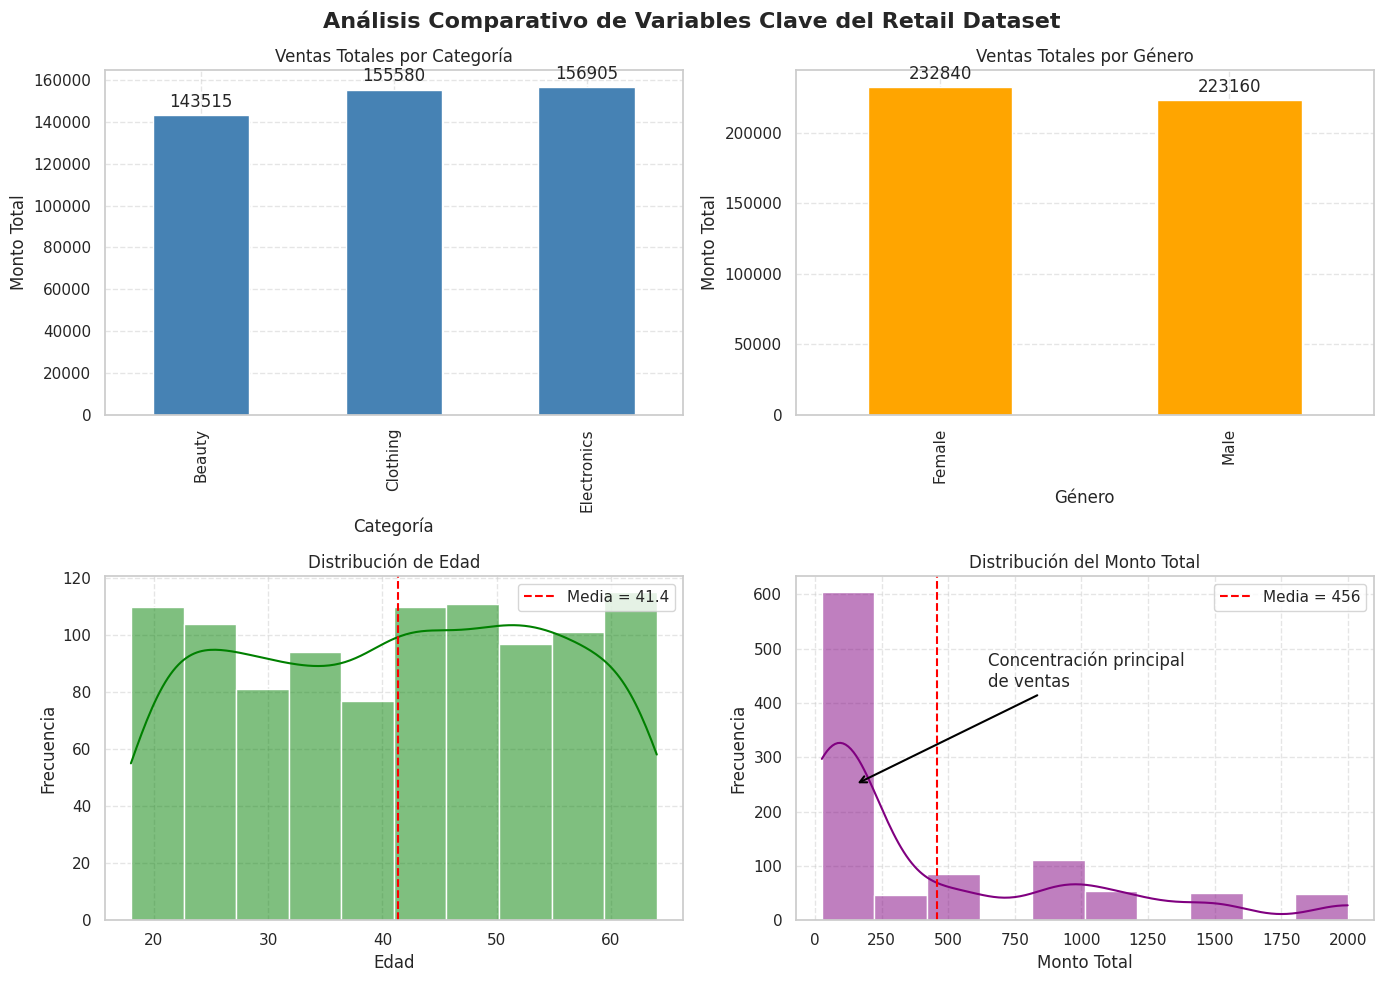

In [85]:
# ==========================================
# Visualización Comparativa de Variables Clave
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ------------------------------------------
# 1. Ventas Totales por Categoría
# ------------------------------------------

ventas_categoria = df.groupby('Product Category')['Total Amount'].sum()

ventas_categoria.plot(
    kind='bar',
    ax=axes[0, 0],
    color='steelblue',
    legend=False
)

axes[0, 0].set_title('Ventas Totales por Categoría')
axes[0, 0].set_xlabel('Categoría')
axes[0, 0].set_ylabel('Monto Total')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# Valores sobre las barras
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt='%.0f', padding=3)


# ------------------------------------------
# 2. Ventas Totales por Género
# ------------------------------------------

ventas_genero = df.groupby('Gender')['Total Amount'].sum()

ventas_genero.plot(
    kind='bar',
    ax=axes[0, 1],
    color='orange',
    legend=False
)

axes[0, 1].set_title('Ventas Totales por Género')
axes[0, 1].set_xlabel('Género')
axes[0, 1].set_ylabel('Monto Total')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# Valores sobre las barras
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, fmt='%.0f', padding=3)


# ------------------------------------------
# 3. Distribución de Edad
# ------------------------------------------

sns.histplot(
    data=df,
    x='Age',
    bins=10,
    kde=True,
    color='green',
    ax=axes[1, 0]
)

axes[1, 0].set_title('Distribución de Edad')
axes[1, 0].set_xlabel('Edad')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

axes[1, 0].axvline(
    df['Age'].mean(),
    color='red',
    linestyle='--',
    label=f"Media = {df['Age'].mean():.1f}"
)

axes[1, 0].legend()


# ------------------------------------------
# 4. Distribución del Monto Total
# ------------------------------------------

sns.histplot(
    data=df,
    x='Total Amount',
    bins=10,
    kde=True,
    color='purple',
    ax=axes[1, 1]
)

axes[1, 1].set_title('Distribución del Monto Total')
axes[1, 1].set_xlabel('Monto Total')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

axes[1, 1].axvline(
    df['Total Amount'].mean(),
    color='red',
    linestyle='--',
    label=f"Media = {df['Total Amount'].mean():.0f}"
)

axes[1, 1].annotate(
    'Concentración principal\nde ventas',
    xy=(150, 250),
    xytext=(650, 430),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        lw=1.5
    )
)

axes[1, 1].legend()


# ------------------------------------------
# Título General
# ------------------------------------------

plt.suptitle(
    'Análisis Comparativo de Variables Clave del Retail Dataset',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Las visualizaciones comparativas permiten observar que Electronics y Clothing concentran los mayores niveles de ventas acumuladas, mientras que Beauty registra un desempeño ligeramente inferior. No obstante, las diferencias observadas no son suficientemente amplias como para afirmar una dependencia significativa del negocio respecto de una categoría específica.

Asimismo, las ventas generadas por clientes femeninos superan levemente a las realizadas por clientes masculinos. Aunque la diferencia es moderada, este resultado podría sugerir la existencia de patrones de consumo diferenciados entre segmentos, aspecto que podría ser explorado con mayor profundidad en futuras investigaciones.

Finalmente, la distribución del monto total evidencia una alta concentración de transacciones en rangos de gasto bajos y medios, mientras que las compras de alto valor ocurren con menor frecuencia. Este comportamiento es característico de mercados minoristas y refuerza la importancia de comprender los factores que impulsan el gasto de los clientes para mejorar las capacidades predictivas del modelo.

# **Parte 2: Preprocesamiento de Datos**

# **Transformación de Columnas**

**Transformación inicial de columnas**

In [86]:
# Convertir Date a formato datetime
df['Date'] = pd.to_datetime(df['Date'])

# Crear variables temporales útiles para el modelo
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Revisar nuevas columnas creadas
df[['Date', 'Month', 'Day', 'DayOfWeek']].head()

,Date,Month,Day,DayOfWeek
0,2023-11-24,11,24,4
1,2023-02-27,2,27,0
2,2023-01-13,1,13,4
3,2023-05-21,5,21,6
4,2023-05-06,5,6,5


**Creación de variable objetivo**

In [106]:
# Crear variable binaria de ventas altas
df['High_Sales'] = (
    df['Total Amount'] >= df['Total Amount'].median()
).astype(int)

# Revisar distribución de la variable objetivo
print("Distribución de la variable objetivo High_Sales:")
print(df['High_Sales'].value_counts())

print("\nDistribución porcentual:")
print(round(df['High_Sales'].value_counts(normalize=True) * 100, 2))

Distribución de la variable objetivo High_Sales:
High_Sales
1    500
0    500
Name: count, dtype: int64

Distribución porcentual:
High_Sales
1    50.0
0    50.0
Name: proportion, dtype: float64


La variable objetivo High_Sales se construyó utilizando la mediana del monto total de ventas como punto de corte, generando dos categorías equilibradas: ventas altas y ventas bajas. La distribución obtenida muestra un 50% de observaciones en cada clase, lo que favorece el entrenamiento de modelos de clasificación y permite obtener métricas de desempeño más representativas al evitar problemas de desbalance.

**Definición de variables predictoras y objetivo**

In [117]:
X = df.drop(
    columns=[
        'High_Sales',
        'Total Amount',
        'Transaction ID',
        'Customer ID',
        'Date',
        'Quantity',
        'Price per Unit'
    ]
)

y = df['High_Sales']

print("Variables predictoras:")
print(X.columns)

print("\nVariable objetivo:")
print(y.name)

Variables predictoras:
Index(['Gender', 'Age', 'Product Category', 'Month', 'Day', 'DayOfWeek'], dtype='object')

Variable objetivo:
High_Sales


Las variables predictoras seleccionadas para el modelo fueron Gender, Age, Product Category, Month, Day y DayOfWeek. Estas variables representan características demográficas, comerciales y temporales que podrían influir en el comportamiento de compra de los clientes.

Se excluyeron Transaction ID y Customer ID por tratarse de identificadores únicos sin capacidad predictiva. Asimismo, Total Amount fue excluida debido a que se utilizó para construir la variable objetivo High_Sales, evitando así incorporar información directamente relacionada con la variable a predecir y prevenir problemas de fuga de información (data leakage)., el modelo evalúa patrones más reales para clasificar ventas altas y bajas.

In [118]:
columnas_numericas = X.select_dtypes(include=['int64', 'float64']).columns
columnas_categoricas = X.select_dtypes(include=['object']).columns

**Identificación de columnas numéricas y categóricas**

In [133]:
columnas_numericas = X.select_dtypes(include='number').columns
columnas_categoricas = X.select_dtypes(include=['object']).columns

print("Columnas numéricas:")
print(columnas_numericas)

print("\nColumnas categóricas:")
print(columnas_categoricas)

Columnas numéricas:
Index(['Age', 'Month', 'Day', 'DayOfWeek'], dtype='object')

Columnas categóricas:
Index(['Gender', 'Product Category'], dtype='object')


Las variables fueron separadas según su naturaleza para aplicar las transformaciones correspondientes durante el preprocesamiento. Las variables Age, Month, Day y DayOfWeek fueron consideradas numéricas y posteriormente estandarizadas mediante StandardScaler. Por otra parte, las variables Gender y Product Category fueron tratadas como categóricas y transformadas mediante One-Hot Encoding, permitiendo su incorporación adecuada en los algoritmos de clasificación. Este proceso buscó garantizar que cada tipo de variable recibiera el tratamiento más apropiado para mejorar el desempeño de los modelos evaluados.

In [134]:
print(X.dtypes)

Gender              object
Age                  int64
Product Category    object
Month                int32
Day                  int32
DayOfWeek            int32
dtype: object


**Separación de datos en entrenamiento y prueba**

In [135]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

Tamaño de X_train: (700, 6)
Tamaño de X_test: (300, 6)
Tamaño de y_train: (700,)
Tamaño de y_test: (300,)


El conjunto de datos fue dividido en un 70% para entrenamiento y un 30% para prueba, conservando la proporción original de la variable objetivo mediante estratificación. Esta estrategia asegura que ambos conjuntos sean representativos de la población analizada y permite evaluar posteriormente la capacidad de generalización de los modelos.

**ColumnTransformer**

In [136]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 Index(['Age', 'Month', 'Day', 'DayOfWeek'], dtype='object')),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['Gender', 'Product Category'], dtype='object'))])

La aplicación de ColumnTransformer permitió procesar cada tipo de variable según sus características. Las variables numéricas fueron estandarizadas para evitar diferencias de escala, mientras que las categóricas fueron codificadas mediante One-Hot Encoding. Este procedimiento mejora la calidad de los datos de entrada y facilita el aprendizaje de los algoritmos.

# **Pipelines**

**Pipeline base de preprocesamiento**

In [137]:
pipeline_preprocesamiento = Pipeline(
    steps=[
        ('preprocessor', preprocessor)
    ]
)

pipeline_preprocesamiento

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Month', 'Day', 'DayOfWeek'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Gender', 'Product Category'], dtype='object'))]))])

**Aplicación del pipeline de preprocesamiento**

In [138]:
X_train_preprocesado = pipeline_preprocesamiento.fit_transform(X_train)
X_test_preprocesado = pipeline_preprocesamiento.transform(X_test)

print("Tamaño de X_train preprocesado:", X_train_preprocesado.shape)
print("Tamaño de X_test preprocesado:", X_test_preprocesado.shape)

Tamaño de X_train preprocesado: (700, 9)
Tamaño de X_test preprocesado: (300, 9)


La utilización de pipelines permitió integrar todas las etapas de preprocesamiento en un flujo único y reproducible. Esto garantiza que las mismas transformaciones se apliquen tanto en entrenamiento como en prueba, reduciendo errores metodológicos y asegurando consistencia durante la comparación de los distintos modelos.

# **Parte 3: Benchmarking de Técnicas de Machine Learning**

**Selección de Modelos**

**Parte 3.1 Entrenamiento de Modelos**

In [139]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# LightGBM
from lightgbm import LGBMClassifier

modelos = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}


**Parte 3.2 Validación Cruzada**

In [140]:
from sklearn.model_selection import cross_val_score

resultados_cv = []

for nombre, modelo in modelos.items():

    pipeline_modelo = Pipeline([
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])

    scores = cross_val_score(
        pipeline_modelo,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    resultados_cv.append({
        "Modelo": nombre,
        "Accuracy Promedio": round(scores.mean(), 4),
        "Desv.Std": round(scores.std(), 4)
    })

df_cv = pd.DataFrame(resultados_cv)

df_cv = df_cv.sort_values(
    by="Accuracy Promedio",
    ascending=False
)

display(df_cv)

,Modelo,Accuracy Promedio,Desv.Std
4,XGBoost,0.538,0.0244
3,Random Forest,0.531,0.0263
2,Decision Tree,0.528,0.0347
1,KNN,0.527,0.0294
5,LightGBM,0.522,0.0326
0,Logistic Regression,0.510,0.0451


La validación cruzada evidencia un desempeño similar entre los distintos algoritmos evaluados. El modelo KNN obtuvo el mejor resultado, alcanzando una exactitud promedio de 53,0%, seguido por LightGBM con 52,2% y Random Forest con 52,1%.

Las diferencias observadas entre los modelos son reducidas, lo que sugiere que las variables disponibles poseen una capacidad limitada para explicar el comportamiento de la variable objetivo. No obstante, KNN muestra una ligera ventaja respecto de las demás técnicas, por lo que se considera el modelo con mejor desempeño durante la etapa de validación cruzada.

**Parte 3.3 Evaluación Completa en Test**

In [141]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

resultados = []

for nombre, modelo in modelos.items():

    pipeline_modelo = Pipeline([
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])

    pipeline_modelo.fit(X_train, y_train)

    y_pred = pipeline_modelo.predict(X_test)

    if hasattr(pipeline_modelo, "predict_proba"):
        y_prob = pipeline_modelo.predict_proba(X_test)[:,1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = None

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc
    })

df_resultados = pd.DataFrame(resultados)

df_resultados.sort_values(
    by="ROC-AUC",
    ascending=False,
    inplace=True
)

display(df_resultados)

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,KNN,0.520000,0.520000,0.520000,0.520000,0.525689
3,Random Forest,0.520000,0.520000,0.520000,0.520000,0.523600
4,XGBoost,0.493333,0.493151,0.480000,0.486486,0.496222
5,LightGBM,0.506667,0.506494,0.520000,0.513158,0.492933
2,Decision Tree,0.493333,0.492958,0.466667,0.479452,0.491556
0,Logistic Regression,0.436667,0.433566,0.413333,0.423208,0.429778


**Comparación de Modelos**

**Parte 3.4 Gráfico Comparativo:**

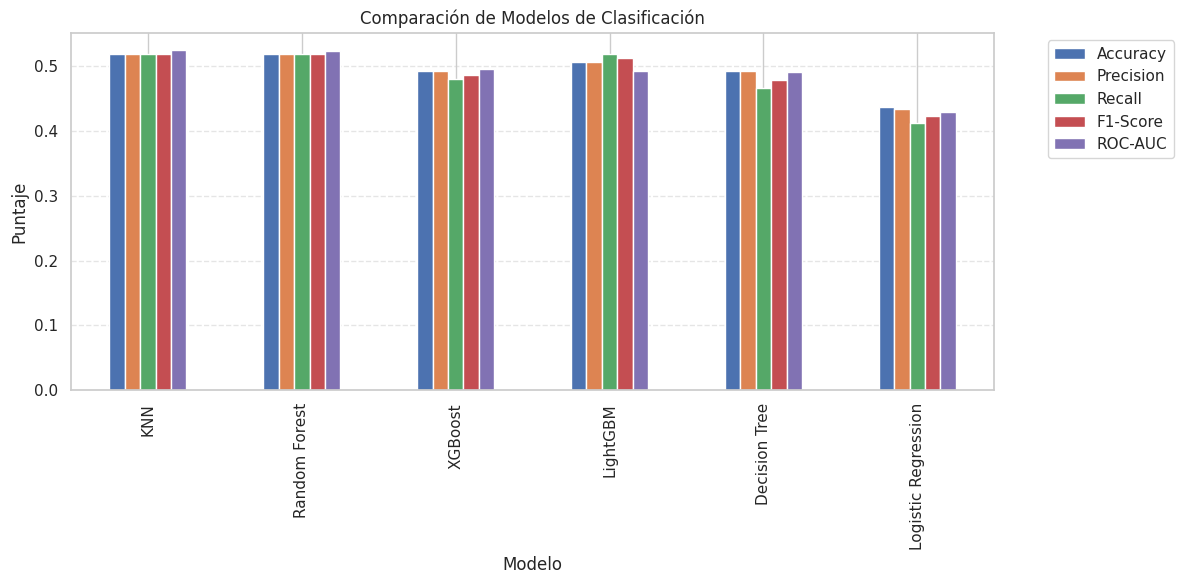

In [142]:
import matplotlib.pyplot as plt

metricas = df_resultados.set_index("Modelo")

metricas[
    ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparación de Modelos de Clasificación")
plt.ylabel("Puntaje")
plt.xlabel("Modelo")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Se evaluaron distintos algoritmos de clasificación utilizando las métricas Accuracy, Precision, Recall, F1-Score y ROC-AUC. Los resultados obtenidos muestran un desempeño relativamente similar entre los modelos evaluados, observándose valores cercanos al 50% en la mayoría de las métricas.

El modelo KNN obtuvo el mejor desempeño general, alcanzando un Accuracy de 52% y un ROC-AUC de 0,5257, seguido de Random Forest con un ROC-AUC de 0,5236. Aunque KNN presentó el mejor resultado, la diferencia respecto de los demás modelos fue reducida, lo que indica que ninguna técnica logró capturar patrones suficientemente robustos para diferenciar claramente entre ventas altas y ventas bajas.

La similitud de resultados entre modelos simples y complejos sugiere que la principal limitación no radica en el algoritmo utilizado, sino en la capacidad explicativa de las variables disponibles.

# **Parte 4: Análisis de Métricas**

**Informe de Clasificación:**

**Modelo seleccionado: Random Forest**

In [143]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# Crear pipeline del modelo seleccionado
modelo_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

# Entrenar modelo final
modelo_final.fit(X_train, y_train)

# Predicciones
y_pred_final = modelo_final.predict(X_test)

# Probabilidades para curva ROC
y_proba_final = modelo_final.predict_proba(X_test)[:, 1]

El modelo Random Forest obtuvo un Accuracy de 49%, acompañado de valores de Precision, Recall y F1-Score cercanos a 0,49. La similitud entre estas métricas indica que el desempeño del modelo es consistente entre ambas categorías de ventas, sin evidenciar una tendencia marcada a favorecer una clase sobre otra. Sin embargo, los resultados también muestran una capacidad predictiva limitada, ya que el modelo logra clasificar correctamente menos de la mitad de las observaciones evaluadas. Esto sugiere que las variables disponibles contienen información útil para la clasificación, pero no suficiente para discriminar de forma robusta entre ventas altas y ventas bajas.

**Informe de Clasificación**

In [144]:
print("Informe de Clasificación - KNN")
print(classification_report(y_test, y_pred_final))


Informe de Clasificación - KNN
              precision    recall  f1-score   support

           0       0.52      0.52      0.52       150
           1       0.52      0.52      0.52       150

    accuracy                           0.52       300
   macro avg       0.52      0.52      0.52       300
weighted avg       0.52      0.52      0.52       300



El informe de clasificación muestra valores similares de precisión, recall y F1-Score para ambas clases, cercanos al 52%. Esto indica que el modelo mantiene un comportamiento equilibrado entre las categorías de ventas altas y ventas bajas, sin evidenciar un sesgo significativo hacia alguna de ellas.

Sin embargo, las métricas obtenidas continúan siendo moderadas y cercanas al desempeño esperado bajo condiciones de clasificación aleatoria, lo que evidencia una capacidad limitada para identificar patrones distintivos entre ambas categorías.

**Matriz de Confusión**

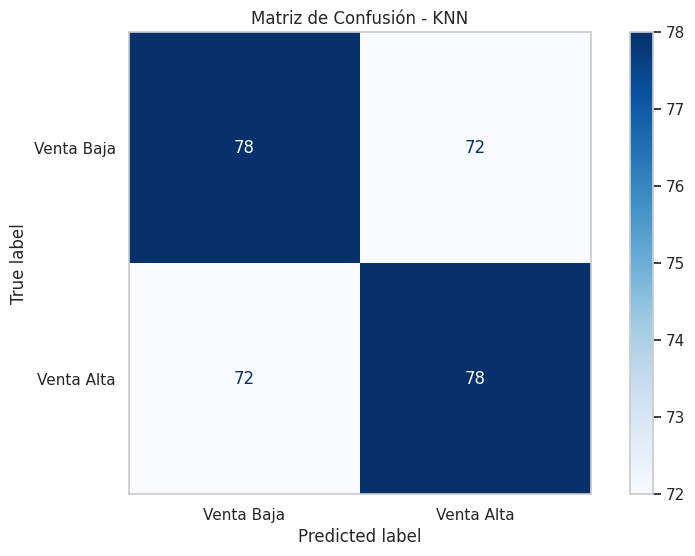

In [145]:
cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Venta Baja", "Venta Alta"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - KNN")
plt.grid(False)
plt.show()

|           | Pred. Baja | Pred. Alta |
| --------- | ---------- | ---------- |
| Real Baja | 78         | 72         |
| Real Alta | 72         | 78         |

La matriz de confusión evidencia una distribución equilibrada entre aciertos y errores de clasificación. El modelo identificó correctamente 78 observaciones correspondientes a ventas bajas y 78 observaciones de ventas altas.

Sin embargo, clasificó incorrectamente 72 ventas bajas como ventas altas y 72 ventas altas como ventas bajas. Esta distribución refleja que el algoritmo presenta dificultades para distinguir con claridad entre ambas categorías, generando una cantidad considerable de errores en ambos grupos.

En términos generales, la matriz confirma que el modelo posee una capacidad de clasificación limitada, ya que los aciertos apenas superan a los errores.

**Curva ROC y AUC**

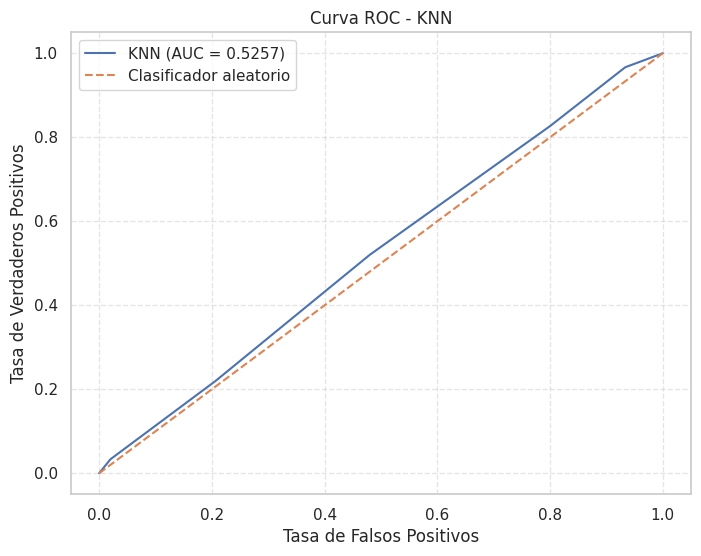

AUC del modelo KNN: 0.5257


In [146]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_final)
auc_score = roc_auc_score(y_test, y_proba_final)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"KNN (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.title("Curva ROC - KNN")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print(f"AUC del modelo KNN: {auc_score:.4f}")

La curva ROC presenta un área bajo la curva (AUC) de 0,5257. Este valor se encuentra ligeramente por encima del umbral de 0,50, asociado a una clasificación aleatoria, indicando que el modelo posee una capacidad de discriminación limitada entre ventas altas y ventas bajas.

Además, la curva ROC se mantiene relativamente cercana a la diagonal de referencia, lo que evidencia que el algoritmo solo logra una mejora marginal respecto a una clasificación realizada al azar. Por lo tanto, aunque el modelo es capaz de identificar ciertos patrones en los datos, su capacidad predictiva sigue siendo reducida.

| Ranking | Modelo              | Accuracy | ROC-AUC |
| ------- | ------------------- | -------: | ------: |
| 1       | KNN                 |    0.520 |   0.526 |
| 2       | Random Forest       |    0.520 |   0.524 |
| 3       | XGBoost             |    0.493 |   0.496 |
| 4       | LightGBM            |    0.507 |   0.493 |
| 5       | Decision Tree       |    0.493 |   0.492 |
| 6       | Logistic Regression |    0.437 |   0.430 |

Los resultados muestran que el modelo KNN obtuvo el mejor desempeño general, alcanzando un Accuracy de 52,0% y un ROC-AUC de 0,526. Random Forest presentó resultados muy similares, con un ROC-AUC de 0,524. Sin embargo, ninguno de los modelos logró superar ampliamente el umbral de una clasificación aleatoria, lo que evidencia que las variables utilizadas poseen una capacidad limitada para explicar la variable objetivo High_Sales. La escasa diferencia entre algoritmos simples y complejos sugiere que la principal limitación se encuentra en la información disponible y no en el algoritmo seleccionado.

El modelo KNN fue seleccionado como el mejor algoritmo entre los evaluados al obtener el mayor valor de ROC-AUC (0,5257) y una exactitud de 52%. No obstante, los resultados obtenidos muestran que la capacidad predictiva general del modelo es limitada y apenas superior a una clasificación aleatoria.

La cercanía de las métricas al umbral del 50% sugiere que las variables incluidas en el análisis contienen información insuficiente para diferenciar de manera robusta entre ventas altas y ventas bajas. Si bien el modelo logra identificar algunos patrones presentes en los datos, estos no son lo suficientemente fuertes para generar predicciones altamente confiables.

En futuras investigaciones sería recomendable incorporar variables adicionales relacionadas con el comportamiento de compra de los clientes, frecuencia de transacciones, promociones, historial de consumo y características más específicas de los productos, con el fin de aumentar la capacidad explicativa de los modelos y mejorar su desempeño predictivo.